# Exploratory Data Analysis

Explore the customer churn dataset from HuggingFace (https://huggingface.co/datasets/d0r1h/customer_churn). We analyze distributions, churn rates by segment, and key drivers for each. Run **00_data_preprocessing** first so `data/processed/customer_churn_features.csv`  exist.

| Source | Churn = 1 means |
|--------|------------------|
| Customer churn | We look at the churn_risk_score column |

## 1. Load data and setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
customer = pd.read_csv(DATA_PROCESSED / "customer_churn_features.csv")
print("customer shape:", customer.shape)
print("\ncustomer (head):")
display(customer.head())

customer shape: (36992, 21)

customer (head):


,age,gender,security_no,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,...,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,tenure_days
0,18,0,XW0DQ7H,2,3,0.0,1,3,2,17.0,...,53005.25,17.0,781.75,1,1,0,1,4,0,136
1,32,0,5K0N3X1,0,4,0.0,1,1,1,16.0,...,12838.38,10.0,697.62,1,0,1,2,5,0,125
2,44,0,1F2TCL3,1,2,1.0,1,1,2,14.0,...,21027.00,22.0,500.69,0,1,1,3,3,1,415
3,37,1,VJGJ33N,0,2,1.0,1,1,1,11.0,...,25239.56,6.0,567.66,0,1,1,4,3,1,428
4,31,0,SVZXCWB,0,2,0.0,0,2,1,20.0,...,24483.66,16.0,663.06,0,1,1,2,3,1,22


## 1b. Derived behavioral segments for agents

To support the Stage 2 AI agents, we enrich the customer dataset with a few
human-interpretable behavioral segments:

- `value_segment`: low / medium / high, based on `avg_transaction_value` quantiles.
- `engagement_segment`: low / medium / high, based on `days_since_last_login` (higher = lower engagement).
- `price_sensitivity`: flag derived from discount usage and offer preferences.
- `support_risk`: flag for customers with past complaints or escalated statuses.
- `profile_tags`: compact semicolon-separated string summarizing the above traits.

In [ ]:
customer = customer.copy()

# Value segment based on avg_transaction_value quantiles
value_q = customer["avg_transaction_value"].quantile([0.33, 0.66])
value_low, value_high = float(value_q.iloc[0]), float(value_q.iloc[1])


def bucket_value(x: float) -> str:
    if x <= value_low:
        return "low"
    if x >= value_high:
        return "high"
    return "medium"


customer["value_segment"] = customer["avg_transaction_value"].apply(bucket_value)

# Engagement segment based on days_since_last_login quantiles (higher = lower engagement)
eng_q = customer["days_since_last_login"].quantile([0.33, 0.66])
eng_low, eng_high = float(eng_q.iloc[0]), float(eng_q.iloc[1])


def bucket_engagement(days: float) -> str:
    if days <= eng_low:
        return "high"  # very recent activity
    if days >= eng_high:
        return "low"   # long time since last login
    return "medium"


customer["engagement_segment"] = customer["days_since_last_login"].apply(bucket_engagement)

# Price sensitivity flag: low value and discount/offer seeking behaviour
customer["price_sensitivity"] = (
    ((customer["avg_transaction_value"] <= value_low) & (customer["used_special_discount"] == 1))
    | (customer["offer_application_preference"] == 1)
).map({True: "high", False: "normal"})

# Support risk flag: any past complaint or escalated complaint status
customer["support_risk"] = (
    (customer["past_complaint"] == 1) | (customer["complaint_status"] > 1)
).astype(int)


def build_profile_tags(row) -> str:
    tags = [f"value_{row['value_segment']}", f"engagement_{row['engagement_segment']}"]
    if row["price_sensitivity"] == "high":
        tags.append("price_sensitive")
    if row["support_risk"] == 1:
        tags.append("support_risk")
    return ";".join(tags)


customer["profile_tags"] = customer.apply(build_profile_tags, axis=1)

# Add to the existing data
OUTPUT_PATH = DATA_PROCESSED / "customer_churn_features.csv"
customer.to_csv(OUTPUT_PATH, index=False)
print(f"Save to {OUTPUT_PATH}")

Saved enriched features with behavioral segments to ../data/processed/customer_churn_features.csv


## 2. Overview: dtypes, describe, missing values

In [22]:
print("customer dtypes:")
print(customer.dtypes)

customer dtypes:
age                               int64
gender                            int64
security_no                      object
region_category                   int64
membership_category               int64
joined_through_referral         float64
preferred_offer_types             int64
medium_of_operation               int64
internet_option                   int64
days_since_last_login           float64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days        float64
points_in_wallet                float64
used_special_discount             int64
offer_application_preference      int64
past_complaint                    int64
complaint_status                  int64
feedback                          int64
churn_risk_score                  int64
tenure_days                       int64
value_segment                    object
engagement_segment               object
price_sensitivity                object
support_risk           

In [23]:
print("customer — describe:")
display(customer.describe())

customer — describe:


,age,gender,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,...,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,tenure_days,support_risk
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,...,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000
mean,37.118161,0.501757,1.076179,2.242458,0.424822,1.010354,1.563689,1.004785,12.771599,279.147450,...,16.181973,688.492829,0.549903,0.552552,0.497135,1.625946,3.072989,0.540982,544.979915,0.497135
std,15.867412,0.503184,1.025918,1.736675,0.494323,0.830325,0.862282,0.816289,5.420212,329.947709,...,8.200415,182.060475,0.497510,0.497237,0.499999,1.216914,2.560848,0.498324,317.778300,0.499999
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,9.000000,60.102500,...,10.000000,624.350000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,268.000000,0.000000
50%,37.000000,1.000000,1.000000,2.000000,0.000000,1.000000,2.000000,1.000000,13.000000,161.765000,...,16.000000,697.620000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,544.000000,0.000000
75%,51.000000,1.000000,2.000000,4.000000,1.000000,2.000000,2.000000,2.000000,16.000000,356.515000,...,22.000000,757.002500,1.000000,1.000000,1.000000,2.000000,5.000000,1.000000,822.000000,1.000000
max,64.000000,2.000000,3.000000,5.000000,1.000000,3.000000,3.000000,2.000000,26.000000,3235.578521,...,73.061995,2069.069761,1.000000,1.000000,1.000000,4.000000,8.000000,1.000000,1095.000000,1.000000


In [24]:
print("customer — missing values:")
print(customer.isna().sum())

customer — missing values:
age                             0
gender                          0
security_no                     0
region_category                 0
membership_category             0
joined_through_referral         0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
days_since_last_login           0
avg_time_spent                  0
avg_transaction_value           0
avg_frequency_login_days        0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
tenure_days                     0
value_segment                   0
engagement_segment              0
price_sensitivity               0
support_risk                    0
profile_tags                    0
dtype: int64


## 3. Churn rate

In [25]:
churn_stats = customer["churn_risk_score"].agg(["mean", "sum", "count"]).to_frame("Value").T
print(f"Overall Churn Risk Mean: {customer['churn_risk_score'].mean():.3f}")
display(churn_stats)

Overall Churn Risk Mean: 0.541


,mean,sum,count
Value,0.540982,20012.0,36992.0


## 4. Distributions of key features

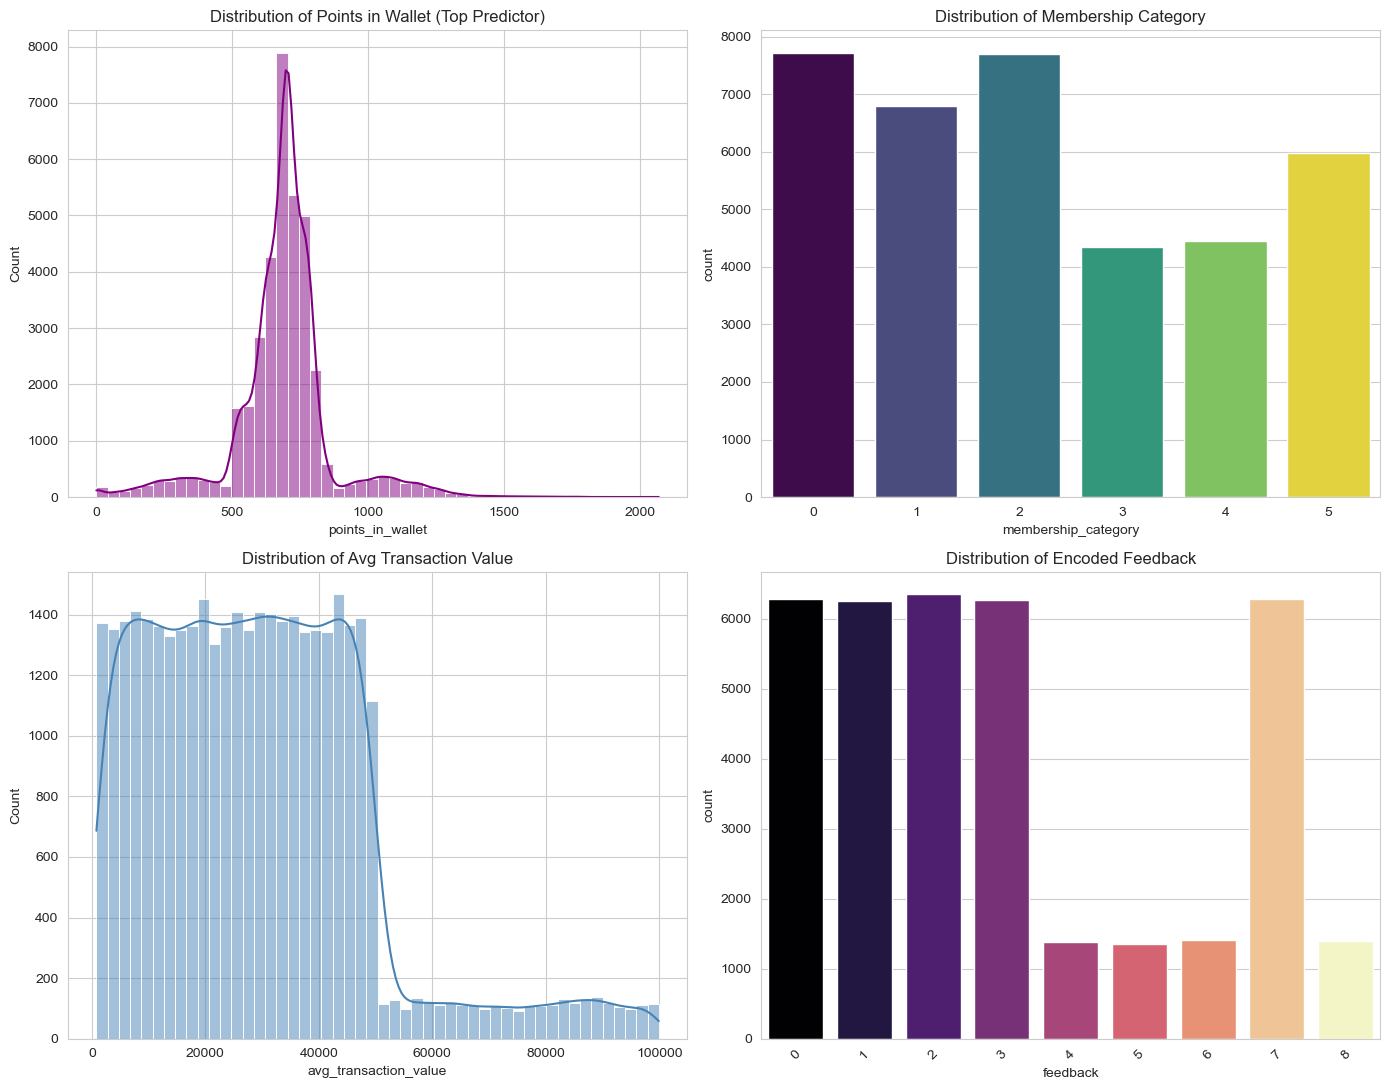

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
sns.set_style("whitegrid")

# op Numeric Driver: Points in Wallet
sns.histplot(customer['points_in_wallet'], bins=50, ax=axes[0, 0], kde=True, color='purple')
axes[0, 0].set_title("Distribution of Points in Wallet (Top Predictor)")

# Top Categorical Driver: Membership Category
# Using countplot for encoded categorical data
sns.countplot(data=customer, x='membership_category', ax=axes[0, 1], palette='viridis', hue='membership_category', legend=False)
axes[0, 1].set_title("Distribution of Membership Category")

# Behavioral Driver: Avg Transaction Value
sns.histplot(customer['avg_transaction_value'], bins=50, ax=axes[1, 0], kde=True, color='steelblue')
axes[1, 0].set_title("Distribution of Avg Transaction Value")

# Sentiment Driver: Feedback
sns.countplot(data=customer, x='feedback', ax=axes[1, 1], palette='magma', hue='feedback', legend=False)
axes[1, 1].set_title("Distribution of Encoded Feedback")
axes[1, 1].tick_params(axis='x', rotation=45) # Rotate labels if they overlap

plt.tight_layout()
plt.show()

## 5. Churn vs features (recency bins for both; satisfaction/avg_review for customer only)

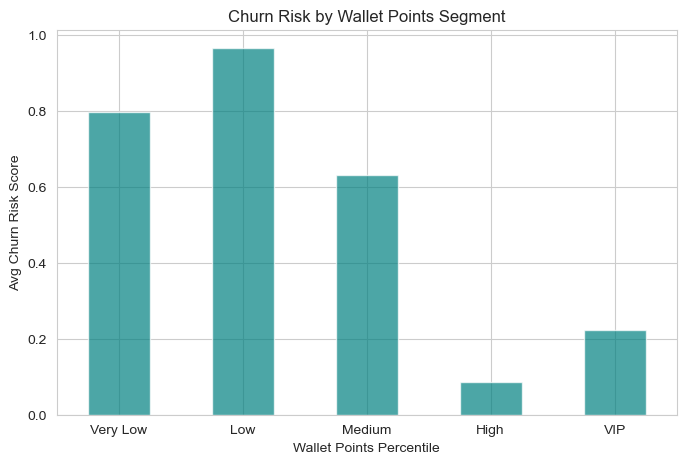

In [27]:
customer["wallet_bin"] = pd.qcut(customer["points_in_wallet"], q=5, labels=["Very Low", "Low", "Medium", "High", "VIP"])
churn_wallet = customer.groupby("wallet_bin", observed=True)["churn_risk_score"].mean()

plt.figure(figsize=(8, 5))
churn_wallet.plot(kind="bar", color="teal", alpha=0.7)
plt.title("Churn Risk by Wallet Points Segment")
plt.ylabel("Avg Churn Risk Score")
plt.xlabel("Wallet Points Percentile")
plt.xticks(rotation=0)
plt.show()

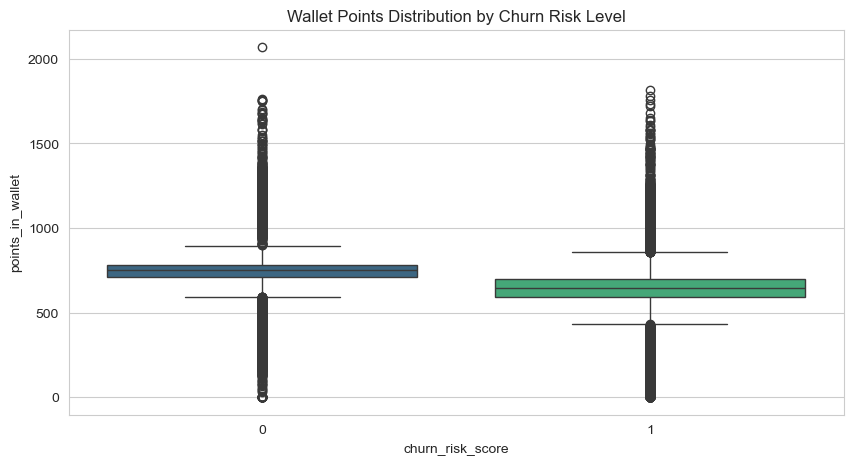

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=customer, x='churn_risk_score', y='points_in_wallet', palette='viridis', hue='churn_risk_score', legend=False)
plt.title("Wallet Points Distribution by Churn Risk Level")
plt.show()

## 6. Correlations (numeric features vs churn)

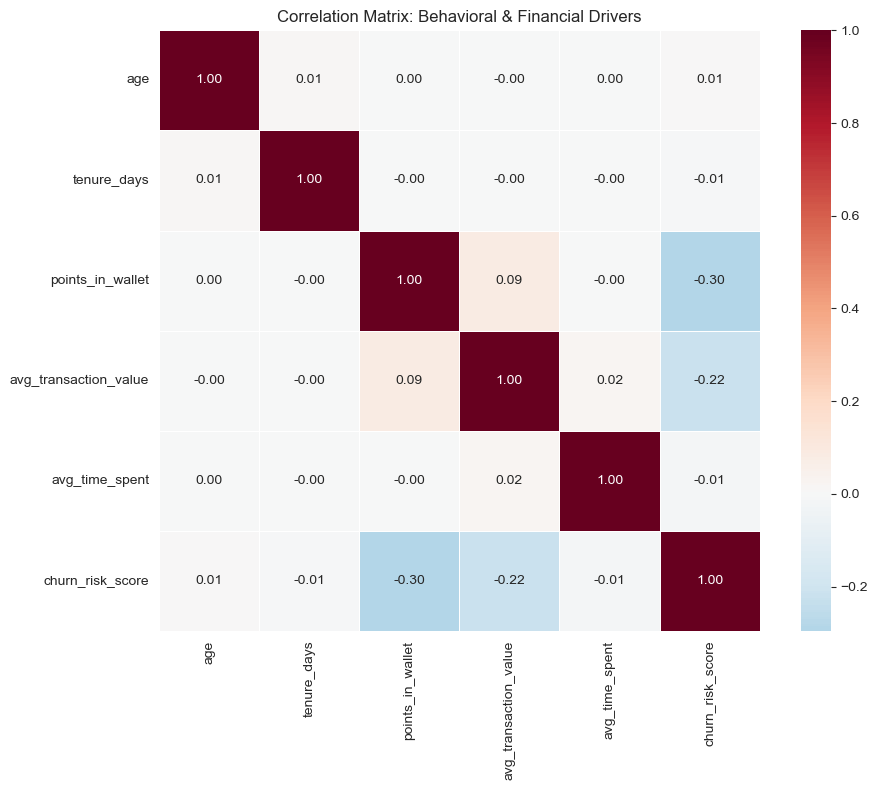

In [29]:
numeric_cols = ["age", "tenure_days", "points_in_wallet", "avg_transaction_value", "avg_time_spent", "churn_risk_score"]
corr_customer = customer[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_customer, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix: Behavioral & Financial Drivers")
plt.tight_layout()
plt.show()